<a href="https://colab.research.google.com/github/mathewkoshy550/Sample_Zomato_DataAnalysis/blob/main/Zomato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("/content/Zomato_75_Restaurants.xlsx")
df.head(5)

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Votes,Average_Cost_for_two,Rating
0,6300000,Izakaya Kikufuji,162,Manila,414 Main Road| Locality 5| Manila,Locality 5,Locality 5| Manila,South Indian,Botswana Pula(P),Yes,No,Yes,No,2,96,500,3.5
1,6300001,Skyline Diner,162,Mandaluyong City,102 Main Road| Locality 8| Mandaluyong City,Locality 8,Locality 8| Mandaluyong City,Cafe,Botswana Pula(P),Yes,Yes,Yes,No,1,1201,2000,2.6
2,6300002,The Curry House,162,Quezon City,580 Main Road| Locality 2| Quezon City,Locality 2,Locality 2| Quezon City,Japanese,Botswana Pula(P),No,Yes,Yes,No,3,1167,700,2.7
3,6300003,Urban Spice,1,Hyderabad,391 Main Road| Locality 7| Hyderabad,Locality 7,Locality 7| Hyderabad,Biryani,Indian Rupees(Rs.),Yes,Yes,Yes,No,4,1413,4000,3.5
4,6300004,Green Bowl,162,Manila,609 Main Road| Locality 15| Manila,Locality 15,Locality 15| Manila,French,Botswana Pula(P),No,Yes,Yes,No,2,187,1100,3.8


In [6]:
print(df.columns.tolist())
# Display first 5 rows
print("First 5 Rows:")
print(df.head())

#2a Shape
print("\nShape:")
print(df.shape)

#2b Column Names
print("\nColumns:")
print(df.columns)

#2c Data Types
print("\nData Types:")
print(df.dtypes)

#2d Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

#3 Duplicate Records
print("\nDuplicate Records:")
print(df.duplicated().sum())

#4 Convert Average_Cost_for_two to numeric
df["Average_Cost_for_two"] = pd.to_numeric(
    df["Average_Cost_for_two"],
    errors="coerce"
)

print("\nUpdated Data Type:")
print(df["Average_Cost_for_two"].dtype)

#5 Statistical Summary
print("\nStatistical Summary:")
print(df.describe(include="all"))

#6a Number of Unique Cities
print("\nNumber of Unique Cities:")
print(df["City"].nunique())

#6b City with Highest Number of Restaurants
print("\nCity with Highest Number of Restaurants:")
print(df["City"].value_counts().head(1))

#6c Most Common Cuisine
print("\nMost Common Cuisine:")
print(df["Cuisines"].value_counts().head(1))



['RestaurantID', 'RestaurantName', 'CountryCode', 'City', 'Address', 'Locality', 'LocalityVerbose', 'Cuisines', 'Currency', 'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Votes', 'Average_Cost_for_two', 'Rating']
First 5 Rows:
   RestaurantID    RestaurantName  CountryCode              City  \
0       6300000  Izakaya Kikufuji          162            Manila   
1       6300001     Skyline Diner          162  Mandaluyong City   
2       6300002   The Curry House          162       Quezon City   
3       6300003       Urban Spice            1         Hyderabad   
4       6300004        Green Bowl          162            Manila   

                                       Address     Locality  \
0            414 Main Road| Locality 5| Manila   Locality 5   
1  102 Main Road| Locality 8| Mandaluyong City   Locality 8   
2       580 Main Road| Locality 2| Quezon City   Locality 2   
3         391 Main Road| Locality 7| Hyderabad   Local

In [8]:



# 1. Average Restaurant Rating
print("Average Restaurant Rating:")
print(df["Rating"].mean())

# 2. Restaurant with Highest Votes
print("\nRestaurant with Highest Votes:")

highest_votes = df.loc[df["Votes"].idxmax()]

print("Restaurant Name :", highest_votes["RestaurantName"])
print("City            :", highest_votes["City"])
print("Votes           :", highest_votes["Votes"])
print("Rating          :", highest_votes["Rating"])

# 3. Average Cost for Two
print("\nAverage Cost for Two:")

df["Average_Cost_for_two"] = pd.to_numeric(
    df["Average_Cost_for_two"],
    errors="coerce"
)

print(df["Average_Cost_for_two"].mean())

# 4. Average Rating based on Online Delivery
print("\nAverage Rating by Online Delivery:")

print(
    df.groupby("Has_Online_delivery")["Rating"].mean()
)


# 5. Average Rating based on Table Booking
print("\nAverage Rating by Table Booking:")

print(
    df.groupby("Has_Table_booking")["Rating"].mean()
)

# 6. Top 10 Cities with Highest Number of Restaurants
print("\nTop 10 Cities with Highest Number of Restaurants:")

print(
    df["City"].value_counts().head(10)
)

Average Restaurant Rating:
3.5119999999999996

Restaurant with Highest Votes:
Restaurant Name : Ocean Grill
City            : Delhi
Votes           : 1467
Rating          : 3.5

Average Cost for Two:
1582.6666666666667

Average Rating by Online Delivery:
Has_Online_delivery
No     3.606061
Yes    3.438095
Name: Rating, dtype: float64

Average Rating by Table Booking:
Has_Table_booking
No     3.468293
Yes    3.564706
Name: Rating, dtype: float64

Top 10 Cities with Highest Number of Restaurants:
City
Manila              13
Mumbai               9
Delhi                9
Taguig City          8
Mandaluyong City     7
Makati City          7
Hyderabad            6
Bangalore            6
Pasig City           5
Quezon City          5
Name: count, dtype: int64


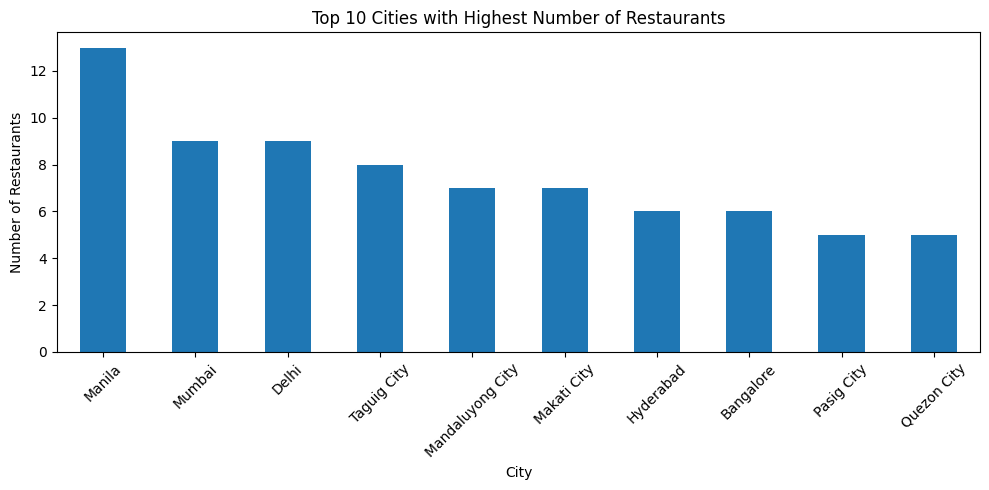

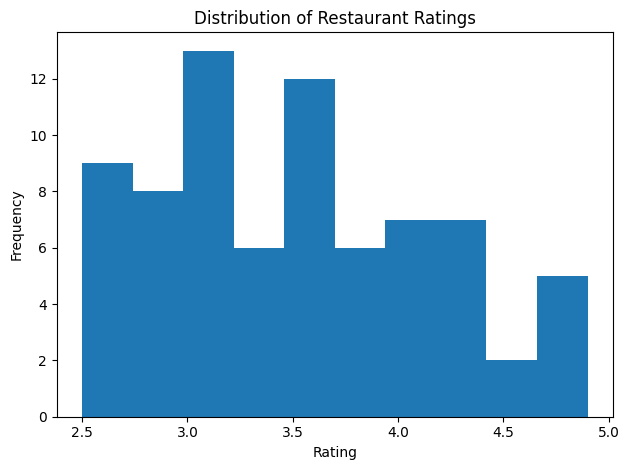

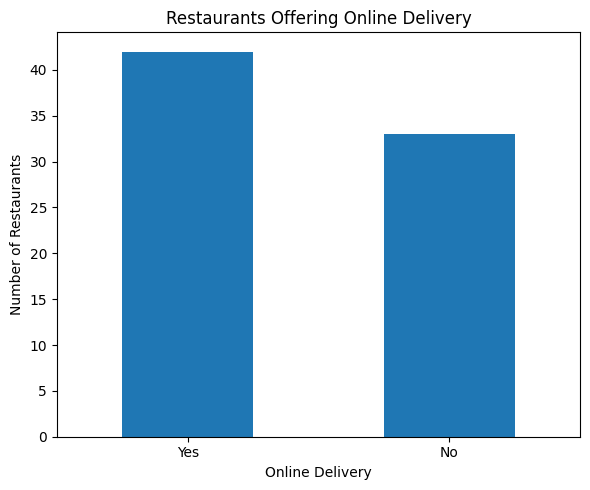

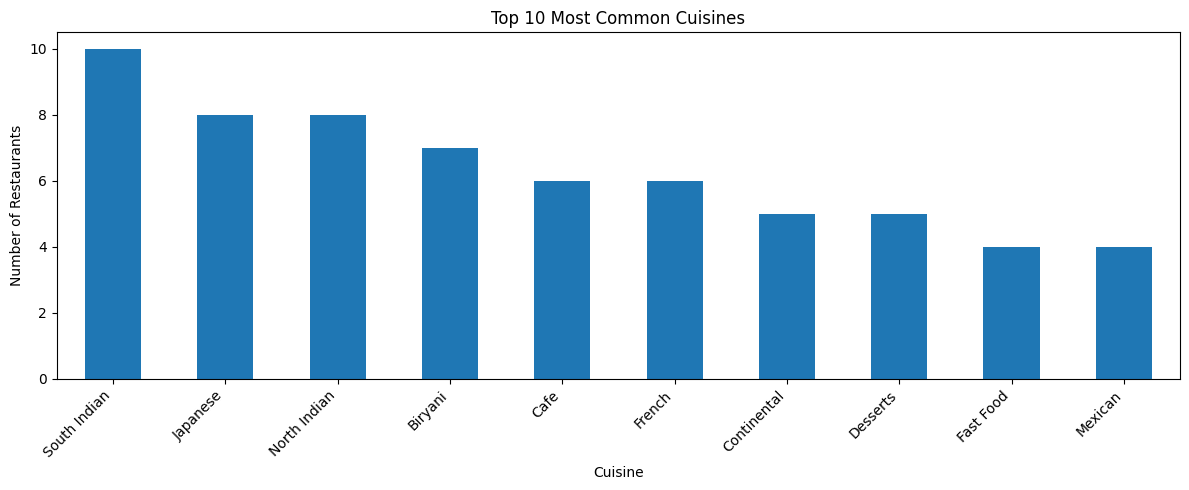

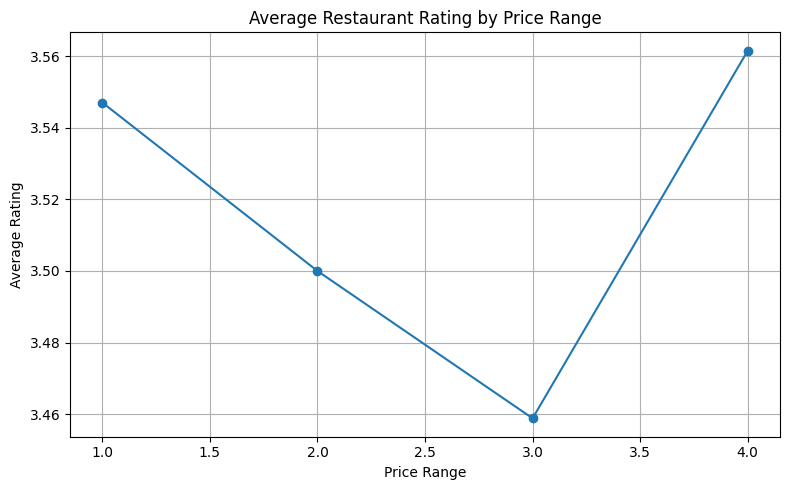

In [9]:


# 1. Bar Chart -Top 10 Cities with Highest Number of Restaurants
top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind="bar")
plt.title("Top 10 Cities with Highest Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Histogram - Distribution of Restaurant Ratings
plt.hist(df["Rating"], bins=10)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3. Bar Chart - Restaurants Offering Online Delivery
online_delivery = df["Has_Online_delivery"].value_counts()

plt.figure(figsize=(6,5))
online_delivery.plot(kind="bar")
plt.title("Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Bar Chart - Top 10 Most Common Cuisines
top_cuisines = df["Cuisines"].value_counts().head(10)

plt.figure(figsize=(12,5))
top_cuisines.plot(kind="bar")
plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5. Line Chart - Average Rating by Price Range
rating_price = df.groupby("Price_range")["Rating"].mean()

plt.figure(figsize=(8,5))
plt.plot(rating_price.index, rating_price.values, marker='o')
plt.title("Average Restaurant Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:


# 1. City with Highest Restaurant Presence
top_city = df["City"].value_counts().idxmax()

print("1. City with Highest Restaurant Presence:")
print(top_city)

# 2. Most Popular Cuisine
top_cuisine = df["Cuisines"].value_counts().idxmax()

print("\n2. Most Popular Cuisine:")
print(top_cuisine)

# 3. Do Restaurants with Online Delivery Have Higher Ratings?
online_rating = df.groupby("Has_Online_delivery")["Rating"].mean()

print("\n3. Average Rating by Online Delivery:")
print(online_rating)

if online_rating["Yes"] > online_rating["No"]:
    print("\nConclusion:")
    print("Restaurants with Online Delivery generally have higher ratings.")
elif online_rating["Yes"] < online_rating["No"]:
    print("\nConclusion:")
    print("Restaurants without Online Delivery generally have higher ratings.")
else:
    print("\nConclusion:")
    print("Both groups have similar average ratings.")

# 4. Do Restaurants with Table Booking Have Better Ratings?
booking_rating = df.groupby("Has_Table_booking")["Rating"].mean()

print("\n4. Average Rating by Table Booking:")
print(booking_rating)

if booking_rating["Yes"] > booking_rating["No"]:
    print("\nConclusion:")
    print("Restaurants offering Table Booking generally receive better ratings.")
elif booking_rating["Yes"] < booking_rating["No"]:
    print("\nConclusion:")
    print("Restaurants without Table Booking generally receive better ratings.")
else:
    print("\nConclusion:")
    print("Both groups have similar average ratings.")

# 5. Final Learning
print("\n5. What Did I Learn From This Dataset?")

print("""
- Explored a real-world restaurant dataset using Pandas.
- Performed data cleaning and checked for missing values and duplicates.
- Analyzed restaurant ratings, costs, votes, cities, and cuisines.
- Created visualizations using Matplotlib.
- Drew business insights based on restaurant data.
""")

1. City with Highest Restaurant Presence:
Manila

2. Most Popular Cuisine:
South Indian

3. Average Rating by Online Delivery:
Has_Online_delivery
No     3.606061
Yes    3.438095
Name: Rating, dtype: float64

Conclusion:
Restaurants without Online Delivery generally have higher ratings.

4. Average Rating by Table Booking:
Has_Table_booking
No     3.468293
Yes    3.564706
Name: Rating, dtype: float64

Conclusion:
Restaurants offering Table Booking generally receive better ratings.

5. What Did I Learn From This Dataset?

- Explored a real-world restaurant dataset using Pandas.
- Performed data cleaning and checked for missing values and duplicates.
- Analyzed restaurant ratings, costs, votes, cities, and cuisines.
- Created visualizations using Matplotlib.
- Drew business insights based on restaurant data.

